# Personalized Healthcare Recommendation System  

This notebook builds a clean, end-to-end ML workflow to **predict a personalized Diet Recommendation** using patient features.

> **Key goals:** clarity, good ML practices, no data leakage, and results that are easy to explain in interviews.


## 1. Problem Statement

Healthcare teams often want **consistent, data-driven** recommendations based on patient profiles.

**Task:** Predict the target label **`Diet_Recommendation`** (multiclass classification) from demographic, lifestyle, and health features.

**Success criteria:**
- Reproducible pipeline (no leakage)
- Strong evaluation with classification report + confusion matrix
- Simple tuning and model selection
- Interpretable insights (feature importance)


## 2. Business Understanding

A model like this can support:
- Faster preliminary guidance for diet planning
- Consistency across cases
- Scalable personalization when experts are limited

In [1]:
# Core imports
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

RANDOM_STATE = 42


## 3. Data Understanding

We load the dataset and do a quick sanity check:
- shape, column names, types
- missing values
- basic descriptive statistics


In [2]:
# Load dataset
df = pd.read_csv("health_data.csv")

print("Shape:", df.shape)
display(df.head())


Shape: (2500, 46)


,Patient_ID,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Diet_Type,Cholesterol,Glucose_Level,...,eGFR,Occupation,Marital_Status,Education_Level,Annual_Income,On_Statins,On_Antihypertensives,Flu_Vaccine_Last_Year,PRS_Alzheimers,Waist_Hip_Ratio
0,1,69,Female,28.5,Ex-smoker,Low,Moderately Active,Mediterranean,236.8,85.5,...,87.7,Unemployed,Divorced,Master,44875.14,0,0,1,0.161,1.02
1,2,32,Male,33.0,Non-smoker,NaN,Lightly Active,Mediterranean,198.3,95.3,...,98.3,Manual Laborer,Widowed,Bachelor,28602.01,1,0,0,0.208,1.04
2,3,89,Female,24.7,Current smoker,Low,Sedentary,Standard,195.0,104.7,...,89.7,Office Worker,Single,PhD,56042.37,0,0,1,0.255,0.93
3,4,78,Female,21.7,Ex-smoker,Moderate,Sedentary,Keto,218.6,115.0,...,95.3,Healthcare,Divorced,PhD,35646.99,0,0,0,0.232,0.95
4,5,38,Male,30.9,Ex-smoker,Moderate,Moderately Active,Mediterranean,200.5,96.2,...,110.8,Educator,Married,PhD,66974.21,0,0,1,0.305,0.81


In [3]:
# Column names and data types
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient_ID                2500 non-null   int64  
 1   Age                       2500 non-null   int64  
 2   Gender                    2500 non-null   object 
 3   BMI                       2500 non-null   float64
 4   Smoking_Status            2500 non-null   object 
 5   Alcohol_Consumption       1524 non-null   object 
 6   Physical_Activity_Level   2500 non-null   object 
 7   Diet_Type                 2500 non-null   object 
 8   Cholesterol               2500 non-null   float64
 9   Glucose_Level             2500 non-null   float64
 10  HbA1c                     2500 non-null   float64
 11  Heart_Disease_Risk        2500 non-null   float64
 12  Diabetes_Risk             2500 non-null   float64
 13  Health_Risk               2500 non-null   float64
 14  Predicte

None

In [4]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Patient_ID,2500.0,1250.500000,721.832160,1.000,625.7500,1250.500,1875.2500,2500.000
Age,2500.0,52.584000,20.817327,18.000,34.0000,52.000,71.0000,89.000
BMI,2500.0,24.910000,4.922678,8.400,21.6000,24.800,28.3000,40.300
Cholesterol,2500.0,200.418320,25.385755,98.400,183.7000,200.700,217.9250,277.600
Glucose_Level,2500.0,99.916720,15.139988,45.700,89.4000,100.400,110.5000,156.700
HbA1c,2500.0,5.537956,0.992282,1.960,4.8700,5.540,6.2100,9.060
Heart_Disease_Risk,2500.0,0.498276,0.284457,0.000,0.2600,0.500,0.7400,1.000
Diabetes_Risk,2500.0,0.487508,0.285887,0.000,0.2400,0.490,0.7300,1.000
Health_Risk,2500.0,0.497872,0.287186,0.000,0.2500,0.500,0.7500,1.000
Predicted_Insurance_Cost,2500.0,11999.720156,2494.846968,3837.920,10214.5775,12013.730,13665.4575,20764.680


In [5]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])


Alcohol_Consumption    976
dtype: int64

- If missing values exist, we handle them before modeling.
- We also confirm which columns are **targets** and which are **features**.


## 4. Data Cleaning

- Remove duplicate rows
- Handle missing values 
- Keep cleaning decisions transparent


In [6]:
# Remove duplicates 
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows.")


Removed 0 duplicate rows.


In [7]:
# Handle missing values
# Drop rows with missing values.
before = df.shape[0]
df = df.dropna()
after = df.shape[0]
print(f"Dropped {before - after} rows with missing values. New shape: {df.shape}")


Dropped 976 rows with missing values. New shape: (1524, 46)


## 5. Exploratory Data Analysis (EDA)

To focus on:
- Target distribution (class balance)
- Key numeric distributions (e.g., BMI)
- Simple relationships that are easy to explain in interviews


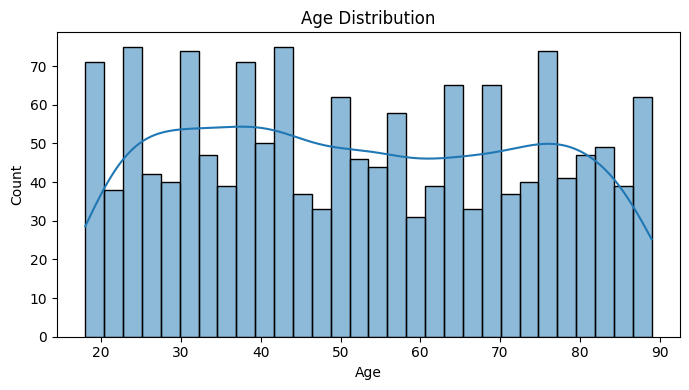

In [8]:
# Age Distribution

plt.figure(figsize=(7, 4))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

The age distribution spans a wide range from approximately 18 to 90 years, indicating that the dataset represents a diverse population across multiple age groups.
The relatively even spread suggests that age is well represented across the dataset, which may help improve the generalizability of the model.
#####

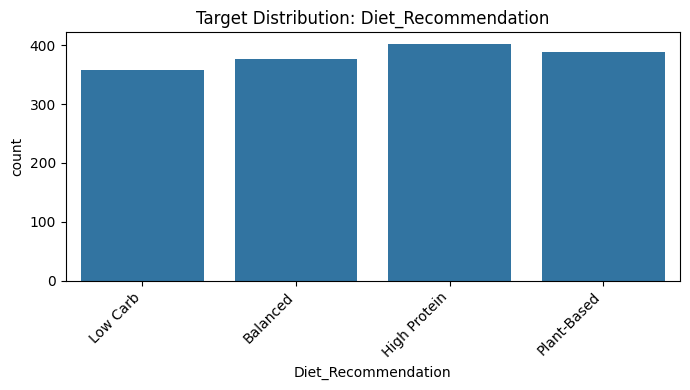

Diet_Recommendation
High Protein    0.263780
Plant-Based     0.254593
Balanced        0.246719
Low Carb        0.234908
Name: proportion, dtype: float64

If one class dominates, macro-F1 is more informative than accuracy.


In [9]:
# Target distribution
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Diet_Recommendation")
plt.title("Target Distribution: Diet_Recommendation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Quick interpretation
counts = df["Diet_Recommendation"].value_counts(normalize=True)
display(counts.rename("proportion"))
print("If one class dominates, macro-F1 is more informative than accuracy.")



#####
The distribution of diet recommendations appears relatively balanced across the four categories, with High Protein, Plant-Based, Balanced, and Low Carb having similar counts.
This balanced class distribution is beneficial for model training as it reduces the risk of class imbalance affecting prediction performance.
######

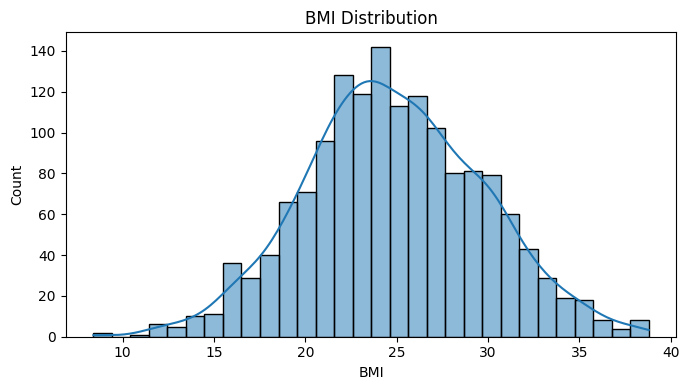

In [10]:
# BMI distribution
if "BMI" in df.columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(df["BMI"], bins=30, kde=True)
    plt.title("BMI Distribution")
    plt.xlabel("BMI")
    plt.tight_layout()
    plt.show()
else:
    print("BMI column not found. Skipping BMI plots.")


The BMI values follow an approximately normal distribution, with most individuals concentrated between 20 and 30, indicating that the majority fall within a typical adult BMI range.
Only a small number of observations appear at the extreme ends, suggesting limited outliers in the dataset.
#####

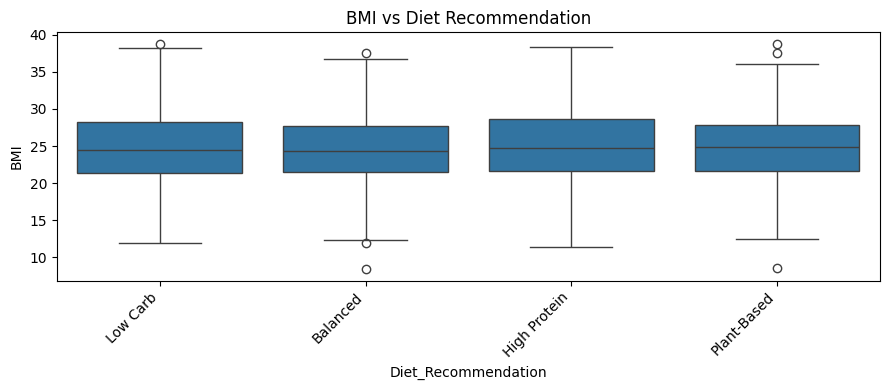

In [23]:
# BMI vs target (if available)
if "BMI" in df.columns:
    plt.figure(figsize=(9, 4))
    sns.boxplot(data=df, x="Diet_Recommendation", y="BMI")
    plt.title("BMI vs Diet Recommendation")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

The BMI distributions across the different diet recommendation categories show similar median values and overlapping ranges, indicating no strong separation between groups.
This suggests that BMI alone may not be sufficient to determine diet recommendations and should be considered alongside other features.
#####

- EDA checks whether features contain signal and whether the target is imbalanced.
- To avoid “random plots” and only keep visuals that support modeling decisions.
#####

## 6. Feature Engineering

- Separate features `X` and target `y`
- Identify numeric vs categorical columns
- Build a **preprocessing pipeline** to avoid data leakage

Using `ColumnTransformer + Pipeline` ensures transforms are fit on training data only.


In [24]:
# Define target and drop columns that should NOT be used as predictors
TARGET = "Diet_Recommendation"

drop_cols = [TARGET]

# Optional: drop ID-like columns if present
for col in ["Patient_ID"]:
    if col in df.columns:
        drop_cols.append(col)

# Optional: drop other label columns to avoid leakage 
for col in ["Exercise_Recommendation"]:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=drop_cols)
y = df[TARGET]

print("X shape:", X.shape)
print("y distribution:")
display(y.value_counts())


X shape: (1524, 43)
y distribution:


Diet_Recommendation
High Protein    402
Plant-Based     388
Balanced        376
Low Carb        358
Name: count, dtype: int64

In [25]:
# Detect column types
categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object", "category", "bool"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)


Numerical columns: ['Age', 'BMI', 'Cholesterol', 'Glucose_Level', 'HbA1c', 'Heart_Disease_Risk', 'Diabetes_Risk', 'Health_Risk', 'Predicted_Insurance_Cost', 'PRS_Cardiometabolic', 'PRS_Type2Diabetes', 'APOE_e4_Carrier', 'BRCA_Pathogenic_Variant', 'Family_History_CVD', 'Family_History_T2D', 'Stress_Level', 'Depression_Score', 'Anxiety_Score', 'Sleep_Hours', 'Sleep_Quality', 'Resting_Heart_Rate', 'HRV', 'Systolic_BP', 'Diastolic_BP', 'LDL', 'HDL', 'Triglycerides', 'CRP', 'eGFR', 'Annual_Income', 'On_Statins', 'On_Antihypertensives', 'Flu_Vaccine_Last_Year', 'PRS_Alzheimers', 'Waist_Hip_Ratio']
Categorical columns: ['Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Diet_Type', 'Occupation', 'Marital_Status', 'Education_Level']


In [26]:
# Preprocessing: scale numeric, one-hot encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="drop"
)


## 7. Train-Test Split

Use of **stratified split** to preserve class distribution across train/test.


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (1219, 43) Test: (305, 43)


## 8. Modeling

Two clear baselines:
1. **Logistic Regression** (fast, interpretable baseline)
2. **Random Forest** (stronger non-linear model)

Evaluate with:
- Accuracy (easy to understand)
- Macro F1 (handles class imbalance better)


In [28]:
def evaluate_classifier(model, X_test, y_test, title="Model"):
    """Evaluate a trained classifier with report + confusion matrix."""
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")

    print(f"{title} | Accuracy: {acc:.3f} | Macro F1: {f1m:.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix: {title}")
    plt.tight_layout()
    plt.show()

    return {"accuracy": acc, "macro_f1": f1m}


Logistic Regression | Accuracy: 0.262 | Macro F1: 0.259

Classification Report:
              precision    recall  f1-score   support

    Balanced       0.18      0.19      0.18        75
High Protein       0.29      0.26      0.27        80
    Low Carb       0.22      0.21      0.22        72
 Plant-Based       0.34      0.38      0.36        78

    accuracy                           0.26       305
   macro avg       0.26      0.26      0.26       305
weighted avg       0.26      0.26      0.26       305



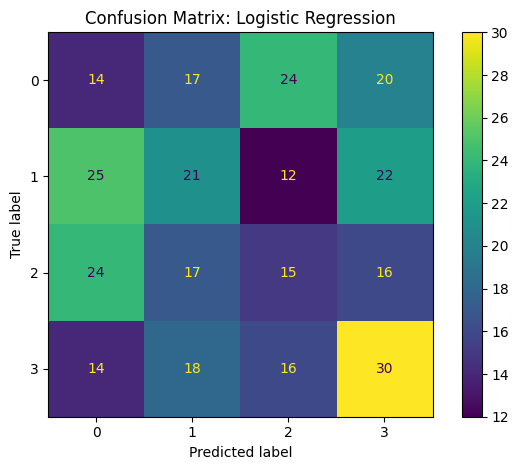

In [29]:
# Logistic Regression pipeline
log_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

log_model.fit(X_train, y_train)
log_metrics = evaluate_classifier(log_model, X_test, y_test, title="Logistic Regression")


Random Forest (Baseline) | Accuracy: 0.239 | Macro F1: 0.242

Classification Report:
              precision    recall  f1-score   support

    Balanced       0.22      0.25      0.23        75
High Protein       0.21      0.23      0.22        80
    Low Carb       0.32      0.25      0.28        72
 Plant-Based       0.23      0.23      0.23        78

    accuracy                           0.24       305
   macro avg       0.25      0.24      0.24       305
weighted avg       0.24      0.24      0.24       305



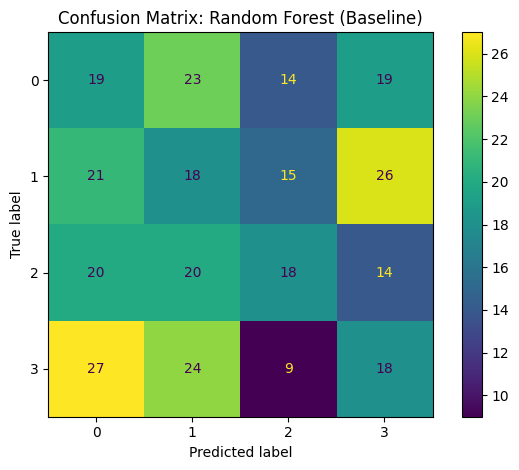

In [30]:
# Random Forest pipeline
rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_model.fit(X_train, y_train)
rf_metrics = evaluate_classifier(rf_model, X_test, y_test, title="Random Forest (Baseline)")


### Quick interpretation
- Logistic Regression is a strong sanity check baseline.
- Random Forest often improves performance by capturing non-linear relationships.


## 9. Hyperparameter Tuning 

Tune Random Forest lightly:
- number of trees
- max depth

Use **StratifiedKFold** and **macro F1** for fair evaluation across classes.


In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 5, 10],
    "clf__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Macro F1:", round(grid.best_score_, 3))


Best Params: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
Best CV Macro F1: 0.253


Random Forest (Tuned) | Accuracy: 0.246 | Macro F1: 0.242

Classification Report:
              precision    recall  f1-score   support

    Balanced       0.24      0.25      0.25        75
High Protein       0.24      0.25      0.24        80
    Low Carb       0.19      0.15      0.17        72
 Plant-Based       0.31      0.32      0.31        78

    accuracy                           0.25       305
   macro avg       0.24      0.24      0.24       305
weighted avg       0.24      0.25      0.24       305



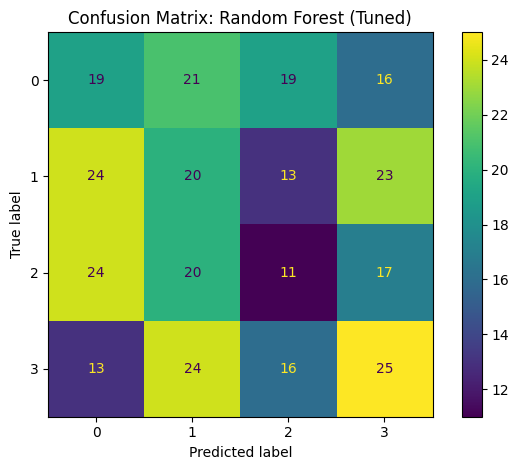

In [32]:
best_model = grid.best_estimator_
final_metrics = evaluate_classifier(best_model, X_test, y_test, title="Random Forest (Tuned)")


## 10. Final Model Selection

To select the model based on **Macro F1** (primary) and accuracy (secondary).
This keeps evaluation aligned with potential class imbalance.


In [33]:
results = pd.DataFrame([
    {"model": "Logistic Regression", **log_metrics},
    {"model": "Random Forest (Baseline)", **rf_metrics},
    {"model": "Random Forest (Tuned)", **final_metrics},
]).sort_values(by="macro_f1", ascending=False)

display(results)
print("Selected final model:", results.iloc[0]["model"])


,model,accuracy,macro_f1
0,Logistic Regression,0.262295,0.258998
2,Random Forest (Tuned),0.245902,0.242497
1,Random Forest (Baseline),0.239344,0.241564


Selected final model: Logistic Regression


## 11. Feature Importance
- Feature importance provides a transparent story about model behavior.

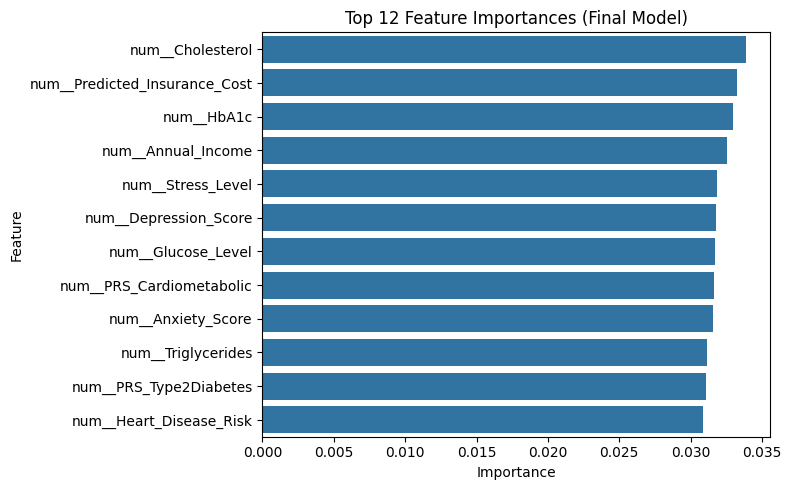

,importance
num__Cholesterol,0.033852
num__Predicted_Insurance_Cost,0.033267
num__HbA1c,0.032973
num__Annual_Income,0.032531
num__Stress_Level,0.031847
num__Depression_Score,0.031806
num__Glucose_Level,0.031710
num__PRS_Cardiometabolic,0.031624
num__Anxiety_Score,0.031565
num__Triglycerides,0.031172


In [34]:
# Feature importance is available for RandomForest
clf = best_model.named_steps["clf"]

# Build feature names after preprocessing
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)

top_k = 12
top_features = importances.head(top_k)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title(f"Top {top_k} Feature Importances (Final Model)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(top_features.to_frame("importance"))


The feature importance analysis indicates that Cholesterol, Predicted Insurance Cost, and HbA1c are among the most influential variables in the model, suggesting that metabolic and financial health indicators play a significant role in determining personalized diet recommendations.

Other factors such as stress level, depression score, glucose level, and cardiometabolic risk also contribute meaningfully, highlighting that both physiological and lifestyle-related attributes collectively influence the model’s predictions.
#####

## 12. Small Practical Enhancement

To add a simple function to generate a recommendation for **one new patient** (single-row input).

In [35]:
def recommend_diet(patient_row: pd.DataFrame) -> str:
    """Predict diet recommendation for a single patient row (DataFrame with same columns as X)."""
    pred = best_model.predict(patient_row)
    return pred[0]

patient_row = X.sample(1, random_state=RANDOM_STATE)
print("Recommendation:", recommend_diet(patient_row))


Recommendation: Plant-Based


## 13. Conclusion

- Built a clean ML pipeline to predict `Diet_Recommendation`
- Used stratified split + macro F1 to evaluate fairly
- Tuned a strong model using cross-validation
- Added interpretability via feature importance
- Provided a simple prediction function for real-world usage

## Summary 

- Built a supervised ML model to predict personalized diet recommendations from patient features.  
- Implemented leak-free preprocessing with a ColumnTransformer + Pipeline.  
- Used stratified splitting and macro-F1 to ensure fair evaluation across classes.  
- Compared baselines and selected a tuned Random Forest using cross-validation.  
- Added interpretability with feature importance to explain what drives predictions.

**Real-world value:** A system like this can support faster preliminary recommendations and consistent personalization at scale.
